# 02 — Comparing the three reconstruction methods

**Task 2:** implement and compare the three reconstruction methods, and discuss image quality,
artifacts and computing time.

---

pyEIT comes with three ways of turning voltages into a picture:

- **Back-projection (BP)** — smears each voltage reading back across the tank and adds everything
  up. No fitting involved, so it is very fast and very rough.
- **Gauss-Newton (JAC)** — works out how sensitive each measurement is to each part of the tank,
  then solves for the conductivity change. Sharper, but needs a smoothing setting to stop it going
  haywire.
- **GREIT** — instead of solving the problem directly, its reconstruction matrix is trained in
  advance so that a small object always comes out as a neat round blob.

Same simulated data for all three, only the method changes.

In [1]:
import os, sys, time, warnings
from pathlib import Path

# Find pyEIT: either installed, or via the PYEIT_PATH environment variable.
try:
    import pyeit
except ImportError:
    for folder in filter(None, [os.environ.get("PYEIT_PATH"), "../pyEIT", "./pyEIT"]):
        if (Path(folder) / "pyeit").is_dir():
            sys.path.insert(0, str(Path(folder).resolve())); break
    import pyeit

sys.path.insert(0, str(Path.cwd()))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import eit_helpers as eit

eit.use_project_style()
figures = Path("figures"); figures.mkdir(exist_ok=True)
tables = Path("results"); tables.mkdir(exist_ok=True)

print(f"{eit.NUMBER_OF_ELECTRODES} electrodes, background conductivity "
      f"{eit.BACKGROUND_CONDUCTIVITY}, images {eit.IMAGE_SIZE}x{eit.IMAGE_SIZE}")

16 electrodes, background conductivity 1.0, images 64x64


In [2]:
fine_mesh, coarse_mesh = eit.build_meshes()
measurement_setup = eit.build_measurement_setup("adjacent")

one_object = [{"centre": [0.5, 0.0], "radius": 0.15, "conductivity": 2.0}]
tank_with_object = eit.add_objects(fine_mesh, one_object)
background_voltages, object_voltages = eit.simulate_measurements(
    fine_mesh, tank_with_object, measurement_setup)
truth = eit.true_picture(fine_mesh, tank_with_object)
print("simulated one object at (0.5, 0)")

simulated one object at (0.5, 0)


## Side by side

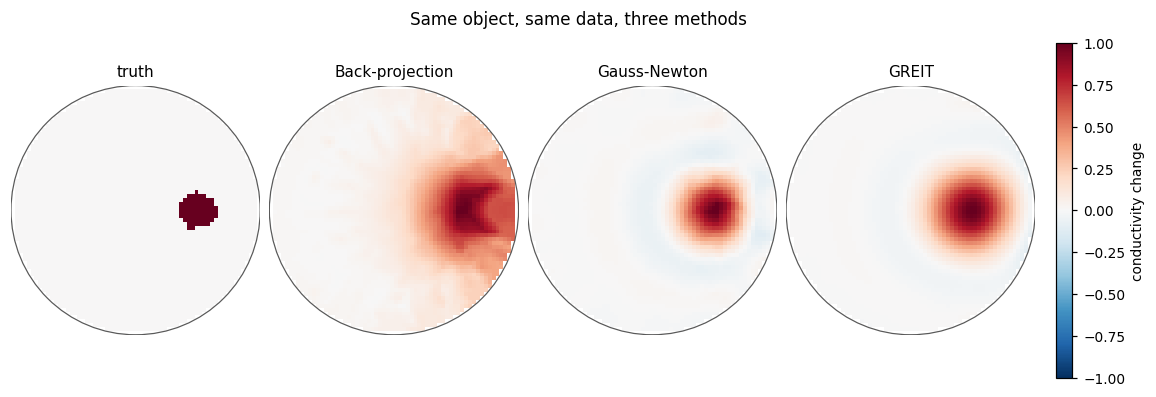

In [3]:
results = eit.reconstruct_with_all_methods(
    coarse_mesh, measurement_setup, object_voltages, background_voltages)

figure, _ = eit.show_images(
    [truth] + [results[method].image for method in eit.METHODS],
    ["truth"] + [eit.METHOD_NAMES[method] for method in eit.METHODS],
    heading="Same object, same data, three methods")
figure.savefig(figures / "02_methods_side_by_side.png")
plt.show()

Back-projection finds roughly the right area but spreads it over a huge part of the tank.
Gauss-Newton gives much the tightest blob. GREIT sits in between, and its blob is the roundest of
the three.

## A slice through the middle

Cutting across the image at the height of the object shows the same thing as numbers: how wide each
peak is, and what each method leaves behind around it.

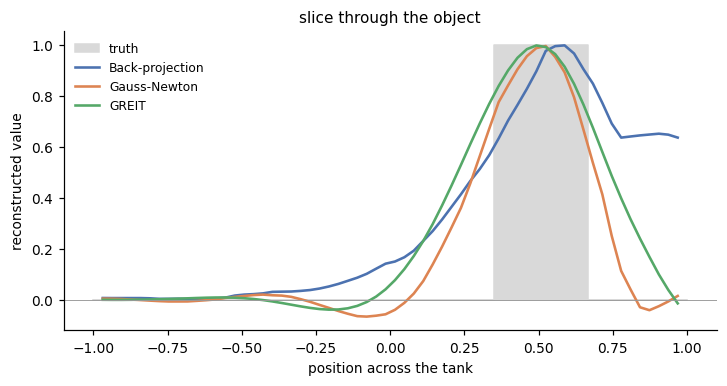

In [4]:
middle_row = eit.IMAGE_SIZE // 2
across = np.linspace(-1, 1, eit.IMAGE_SIZE)

figure, axis = plt.subplots(figsize=(6.5, 3.4), constrained_layout=True)
axis.fill_between(across, np.nan_to_num(truth[middle_row], nan=0.0)
                  / np.nanmax(truth[middle_row]),
                  color="0.85", step="mid", label="truth")
for method in eit.METHODS:
    axis.plot(across, results[method].scaled[middle_row], lw=1.7,
              color=eit.METHOD_COLOURS[method], label=eit.METHOD_NAMES[method])
axis.axhline(0, lw=0.6, color="0.6")
axis.set_xlabel("position across the tank"); axis.set_ylabel("reconstructed value")
axis.set_title("slice through the object")
axis.legend(fontsize=8)
figure.savefig(figures / "02_slice.png")
plt.show()

The dips just either side of the Gauss-Newton peak are the **ringing** artifact: the method
overshoots into negative values next to the object, which in a real image looks like a fake
low-conductivity ring. GREIT shows much less of it and back-projection almost none — but
back-projection pays for that with a peak roughly three times too wide.

## The scores

In [5]:
score_rows = []
for method in eit.METHODS:
    score_rows.append(dict(method=eit.METHOD_NAMES[method],
                           **eit.score_image(truth, results[method].image),
                           visibility=eit.contrast_to_noise(results[method].image, truth)))
scores = pd.DataFrame(score_rows).round(3)
scores.to_csv(tables / "02_scores.csv", index=False)
scores

,method,size,position_error,shape_error,ringing,brightness,visibility
0,Back-projection,0.490,0.042,0.075,0.000,0.175,3.256
1,Gauss-Newton,0.285,0.012,0.024,0.248,0.046,6.729
2,GREIT,0.356,0.012,0.008,0.097,0.080,5.137


The real object has radius 0.15, so the `size` column says how much each method exaggerates it:
Gauss-Newton is about twice too big, GREIT about 2.4 times, back-projection over three times.

There is no outright winner. Gauss-Newton is the sharpest and most accurately placed, GREIT has the
best shape and much less ringing, back-projection has almost no ringing but is far too blurry to be
useful for anything quantitative.

## How long they take

Two separate costs: a one-off setup when the mesh and electrode layout are fixed, and then one
quick calculation per frame.

In [6]:
timing_rows = []
for method in eit.METHODS:
    solver, setup_seconds, _ = eit.prepare_method(method, coarse_mesh, measurement_setup)
    for _ in range(3):                       # warm up
        eit.reconstruct_image(method, coarse_mesh, measurement_setup, object_voltages,
                              background_voltages, prepared_solver=solver)
    frame_times = [eit.reconstruct_image(method, coarse_mesh, measurement_setup,
                                         object_voltages, background_voltages,
                                         prepared_solver=solver).solve_seconds
                   for _ in range(20)]
    timing_rows.append(dict(method=eit.METHOD_NAMES[method],
                            setup_seconds=round(setup_seconds, 3),
                            per_frame_ms=round(float(np.median(frame_times)) * 1e3, 3),
                            frames_per_second=int(1 / float(np.median(frame_times)))))
timings = pd.DataFrame(timing_rows)
timings.to_csv(tables / "02_timings.csv", index=False)
timings

,method,setup_seconds,per_frame_ms,frames_per_second
0,Back-projection,0.048,0.297,3362
1,Gauss-Newton,0.264,1.565,638
2,GREIT,0.998,1.713,583


Back-projection sets up almost instantly because it never has to invert anything. The other two
have to build and invert a sensitivity matrix, which costs noticeably more.

Once that is done, though, every method reconstructs a frame in a couple of milliseconds — hundreds
of frames per second. So for live imaging the choice of method costs nothing; only the one-off
setup differs.

## What noise does to them

Real measurements are noisy. Adding random noise to the voltages at a few different levels shows
which methods hold up. (60 dB is roughly decent lab hardware; 30 dB is bad.)

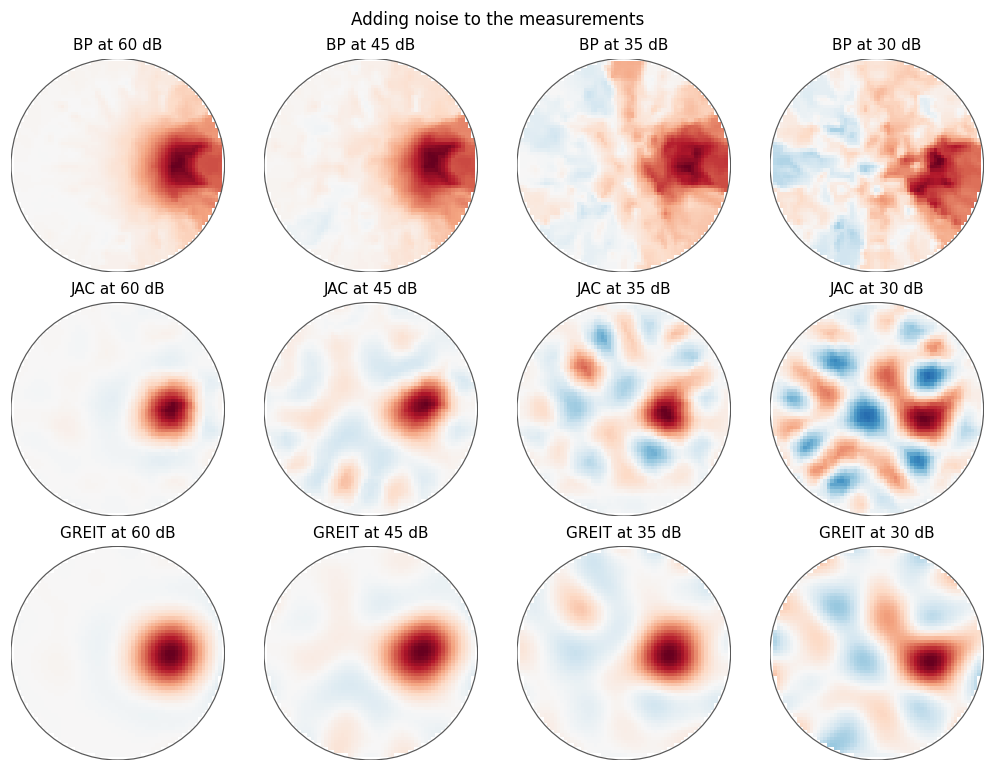

method,Back-projection,GREIT,Gauss-Newton
noise_db,,,
60,3.25,5.12,6.64
45,3.14,4.92,5.72
35,2.92,4.24,3.40
30,2.29,2.90,1.68


In [7]:
noise_levels = [60, 45, 35, 30]

figure, axes = plt.subplots(len(eit.METHODS), len(noise_levels),
                            figsize=(2.3 * len(noise_levels), 2.3 * len(eit.METHODS)),
                            constrained_layout=True)
noise_rows = []
for row, method in enumerate(eit.METHODS):
    solver, setup_seconds, _ = eit.prepare_method(method, coarse_mesh, measurement_setup)
    for column, noise_db in enumerate(noise_levels):
        visibility_scores = []
        for repeat in range(5):
            generator = np.random.default_rng([eit.RANDOM_SEED, noise_db, repeat])
            noisy_background, noisy_object = eit.add_measurement_noise(
                background_voltages, object_voltages, noise_db, generator)
            noisy_result = eit.reconstruct_image(
                method, coarse_mesh, measurement_setup, noisy_object, noisy_background,
                prepared_solver=solver)
            visibility_scores.append(eit.contrast_to_noise(noisy_result.image, truth))
        eit.show_image(axes[row, column], noisy_result.scaled,
                       title=f"{eit.METHOD_SHORT[method]} at {noise_db} dB")
        noise_rows.append(dict(method=eit.METHOD_NAMES[method], noise_db=noise_db,
                               visibility=round(float(np.mean(visibility_scores)), 2)))
figure.suptitle("Adding noise to the measurements", fontsize=11)
figure.savefig(figures / "02_noise.png")
plt.show()

noise_table = pd.DataFrame(noise_rows).pivot(
    index="noise_db", columns="method", values="visibility").sort_index(ascending=False)
noise_table.to_csv(tables / "02_noise.csv")
noise_table

The table is the *visibility* score — how clearly the object stands out from the background,
averaged over 5 random noise runs. Below about 2 the object is hard to pick out at all.

The interesting bit is that the ranking **changes**. On clean data Gauss-Newton wins comfortably.
As the noise gets worse it falls off fastest, and by 35 dB GREIT has already overtaken it. That makes sense
from how they work: Gauss-Newton's sharpness comes from trusting small differences in the data, and
those are exactly what noise destroys first. GREIT has noise handling built into how its matrix is
trained.

---

## What I took away from this notebook

- **Gauss-Newton** gives the sharpest, best-placed blob on clean data, but the most ringing and the
  worst behaviour once noise appears.
- **GREIT** is a bit blurrier but has the roundest blobs, much less ringing, and holds up best when
  the data get noisy. Good all-rounder.
- **Back-projection** is by far the cheapest to set up and barely rings, but its blob is three times
  too big — fine as a quick look, not for measuring anything.
- Setup cost differs a lot between methods; per-frame cost basically doesn't. All three run
  comfortably in real time.
- No method gets the size right. Everything comes out 2–3× too big.

**Next:** [03 — where the object sits](03_object_position.ipynb)